# FASE 2 — EDA Orientado a Predicción

**Objetivo:** Analizar y responder cuantitativamente qué señales de telemetría, patrones de errores e historial de mantenimiento cambian antes de que ocurra una falla, evaluando la viabilidad de las variables para el modelado predictivo con el `master_dataset.parquet`.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

Configuración inicial de librerías de visualización y estilos gráficos para el análisis.

## 1. Carga y Verificación del Master Dataset

**Justificación:** Cargar el dataset analítico unificado (`master_dataset.parquet`) producido en el notebook `02_data_cleaning.ipynb` y verificar su estructura general, volumen y tipos de datos.

In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/main/data/interim/master_dataset.parquet"

master_df = pd.read_parquet(url)
print(master_df.shape)


(876100, 19)


El dataset contiene **876,100 filas × 19 columnas**, cubriendo **100 máquinas únicas** durante 2015. No hay valores nulos en las columnas de telemetría, lo que indica una calidad de datos consistente.

In [11]:
# Carga del dataset integrado en local o main
#master_df = pd.read_parquet("../data/interim/master_dataset.parquet")

print("=== INFORMACIÓN GENERAL DEL MASTER DATASET ===")
print(f"Dimensiones del dataset: {master_df.shape[0]:,} filas x {master_df.shape[1]} columnas")
print(f"Rango temporal: desde {master_df['datetime'].min()} hasta {master_df['datetime'].max()}")
print(f"Total de máquinas únicas: {master_df['machineID'].nunique()}")
print("\n--- Estructura de Columnas y Tipos ---")
master_df.info()

=== INFORMACIÓN GENERAL DEL MASTER DATASET ===
Dimensiones del dataset: 876,100 filas x 19 columnas
Rango temporal: desde 2015-01-01 06:00:00 hasta 2016-01-01 06:00:00
Total de máquinas únicas: 100

--- Estructura de Columnas y Tipos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   datetime                                 876100 non-null  datetime64[ns]
 1   machineID                                876100 non-null  int64         
 2   volt                                     876100 non-null  float64       
 3   rotate                                   876100 non-null  float64       
 4   pressure                                 876100 non-null  float64       
 5   vibration                                876100 non-null  float64       
 6   model                 

El dataset abarca desde el 1 de enero de 2015 hasta el 1 de enero de 2016, con un registro horario continuo. La estructura es consistente: 19 columnas con tipos de datos correctos (datetime, numéricos, categóricos).

## 2. Análisis de Fallas y Desbalance de Clases (Target: `failure_next_24h`)

**Justificación:** Evaluar la frecuencia real de eventos positivos (`failure_next_24h = 1`) frente a observaciones normales (`0`). Esto permite medir el grado de desbalance de clases y definir las métricas de evaluación adecuadas para el modelo (ej. Precision, Recall, PR-AUC).

=== CONTEO DE CLASES (Target: failure_next_24h) ===
Clase 0 [Normal (0)]: 858,916 instancias (98.04%)
Clase 1 [Pre-Falla (1)]: 17,184 instancias (1.96%)


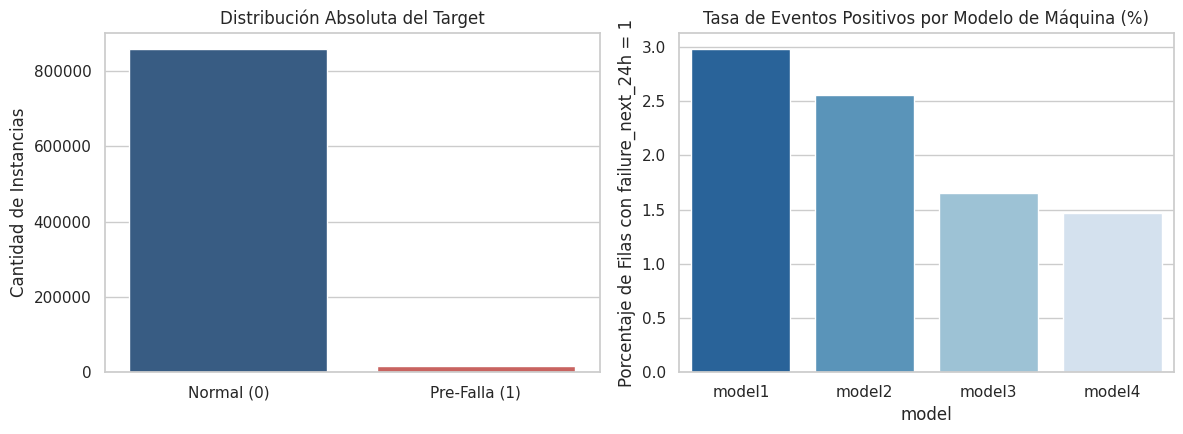


--- Desglose de Fallas por Modelo ---
        Total Filas  Fallas 24h  % Positivo
model                                      
model1       140176        4179    2.981252
model2       148937        3810    2.558129
model3       306635        5073    1.654410
model4       280352        4122    1.470294


In [12]:
# Conteo y proporciones de la variable objetivo
counts = master_df['failure_next_24h'].value_counts()
percentages = master_df['failure_next_24h'].value_counts(normalize=True) * 100

print("=== CONTEO DE CLASES (Target: failure_next_24h) ===")
for val, count in counts.items():
    label = "Pre-Falla (1)" if val == 1 else "Normal (0)"
    print(f"Clase {val} [{label}]: {count:,} instancias ({percentages[val]:.2f}%)")

# Gráfico de desbalance de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=['Normal (0)', 'Pre-Falla (1)'], y=counts.values, ax=axes[0], palette=['#2b5c8f', '#d9534f'], hue=['Normal (0)', 'Pre-Falla (1)'], legend=False)
axes[0].set_title('Distribución Absoluta del Target')
axes[0].set_ylabel('Cantidad de Instancias')

# Fallas por Modelo de Máquina
failure_by_model = master_df.groupby('model')['failure_next_24h'].agg(['count', 'sum', 'mean'])
failure_by_model['percentage'] = failure_by_model['mean'] * 100

sns.barplot(x=failure_by_model.index, y=failure_by_model['percentage'], ax=axes[1], palette='Blues_r', hue=failure_by_model.index, legend=False)
axes[1].set_title('Tasa de Eventos Positivos por Modelo de Máquina (%)')
axes[1].set_ylabel('Porcentaje de Filas con failure_next_24h = 1')

plt.tight_layout()
plt.show()

print("\n--- Desglose de Fallas por Modelo ---")
print(failure_by_model[['count', 'sum', 'percentage']].rename(columns={'count': 'Total Filas', 'sum': 'Fallas 24h', 'percentage': '% Positivo'}))

**Desbalance extremo de clases:** solo el **1.96%** de las instancias (~1 de cada 49) representa un estado de pre-falla. Esto exige métricas de evaluación robustas como **PR-AUC** y **Recall**. El modelo `model1` concentra la mayor tasa de eventos positivos (2.98%).

## 3. Distribución de Telemetría: Estado Normal vs. Pre-Falla

**Justificación:** Comparar las mediciones de los sensores (`volt`, `rotate`, `pressure`, `vibration`) durante la operación normal vs. las 24 horas previas a una falla para identificar desvíos físicos significativos.

=== COMPARACIÓN DE TELEMETRÍA (Media y Desviación Estándar) ===
   Sensor  Normal Mean  Pre-Falla Mean  Delta Mean  Normal Std  Pre-Falla Std
     volt       170.67          175.94        5.26       15.44          17.92
   rotate       447.17          418.56      -28.61       52.27          64.05
 pressure       100.77          105.30        4.53       10.95          14.50
vibration        40.34           42.75        2.41        5.32           6.90


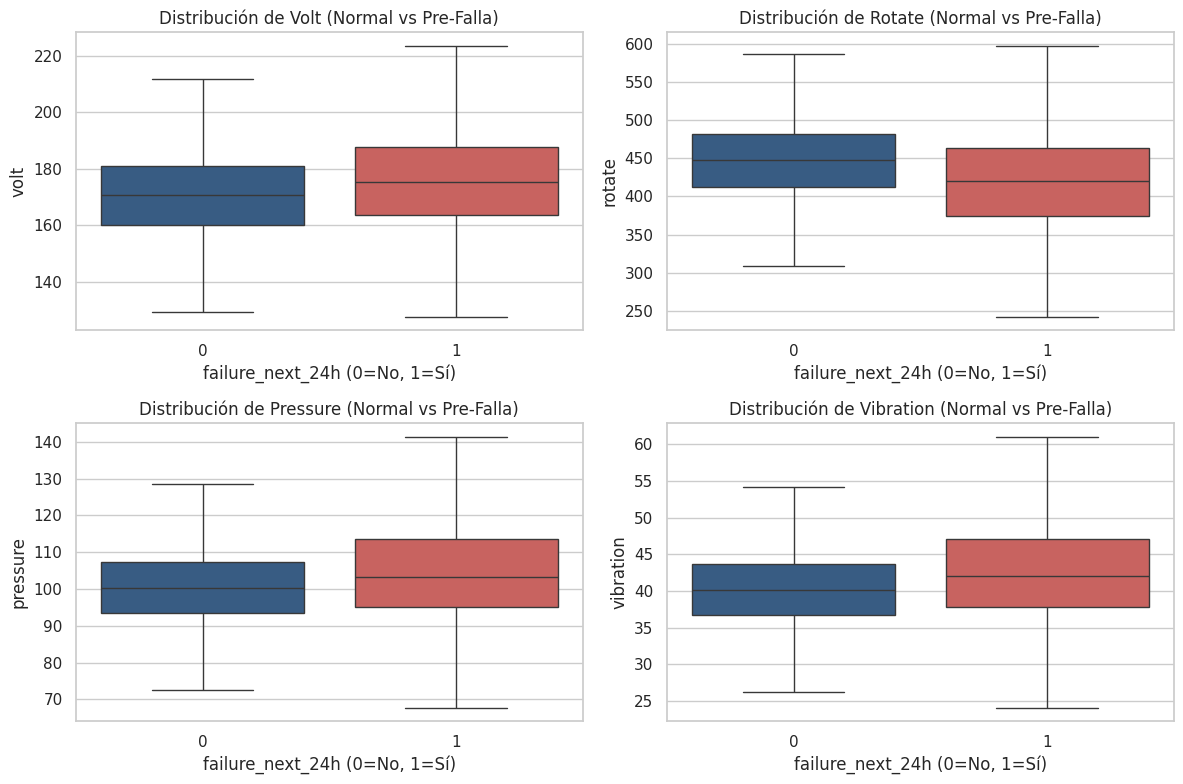

In [13]:
sensors = ['volt', 'rotate', 'pressure', 'vibration']

# Resumen estadístico comparativo
summary_list = []
for s in sensors:
    normal_mean = master_df[master_df['failure_next_24h'] == 0][s].mean()
    fail_mean = master_df[master_df['failure_next_24h'] == 1][s].mean()
    normal_std = master_df[master_df['failure_next_24h'] == 0][s].std()
    fail_std = master_df[master_df['failure_next_24h'] == 1][s].std()
    summary_list.append({
        'Sensor': s,
        'Normal Mean': round(normal_mean, 2),
        'Pre-Falla Mean': round(fail_mean, 2),
        'Delta Mean': round(fail_mean - normal_mean, 2),
        'Normal Std': round(normal_std, 2),
        'Pre-Falla Std': round(fail_std, 2)
    })

summary_df = pd.DataFrame(summary_list)
print("=== COMPARACIÓN DE TELEMETRÍA (Media y Desviación Estándar) ===")
print(summary_df.to_string(index=False))

# Boxplots comparativos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, s in enumerate(sensors):
    sns.boxplot(x='failure_next_24h', y=s, data=master_df, ax=axes[idx], palette=['#2b5c8f', '#d9534f'], hue='failure_next_24h', legend=False, showfliers=False)
    axes[idx].set_title(f'Distribución de {s.capitalize()} (Normal vs Pre-Falla)')
    axes[idx].set_xlabel('failure_next_24h (0=No, 1=Sí)')

plt.tight_layout()
plt.show()

Comparación de telemetría entre operación normal y pre-falla:
- **volt**: incremento de +5.26V en pre-falla
- **pressure**: aumento de +4.53 psi
- **rotate**: caída de ~28 RPM (posible sobrecarga mecánica)
- **vibration**: leve incremento con mayor volatilidad
Las distribuciones se superponen, limitando el poder predictivo individual de cada sensor.

## 4. Análisis de Tendencias Temporales y Deterioro Físico Antes de una Falla

**Justificación:** Inspeccionar el comportamiento temporal de los sensores en una máquina específica durante las 48 horas previas a un evento de falla para observar patrones progresivos de degradación.

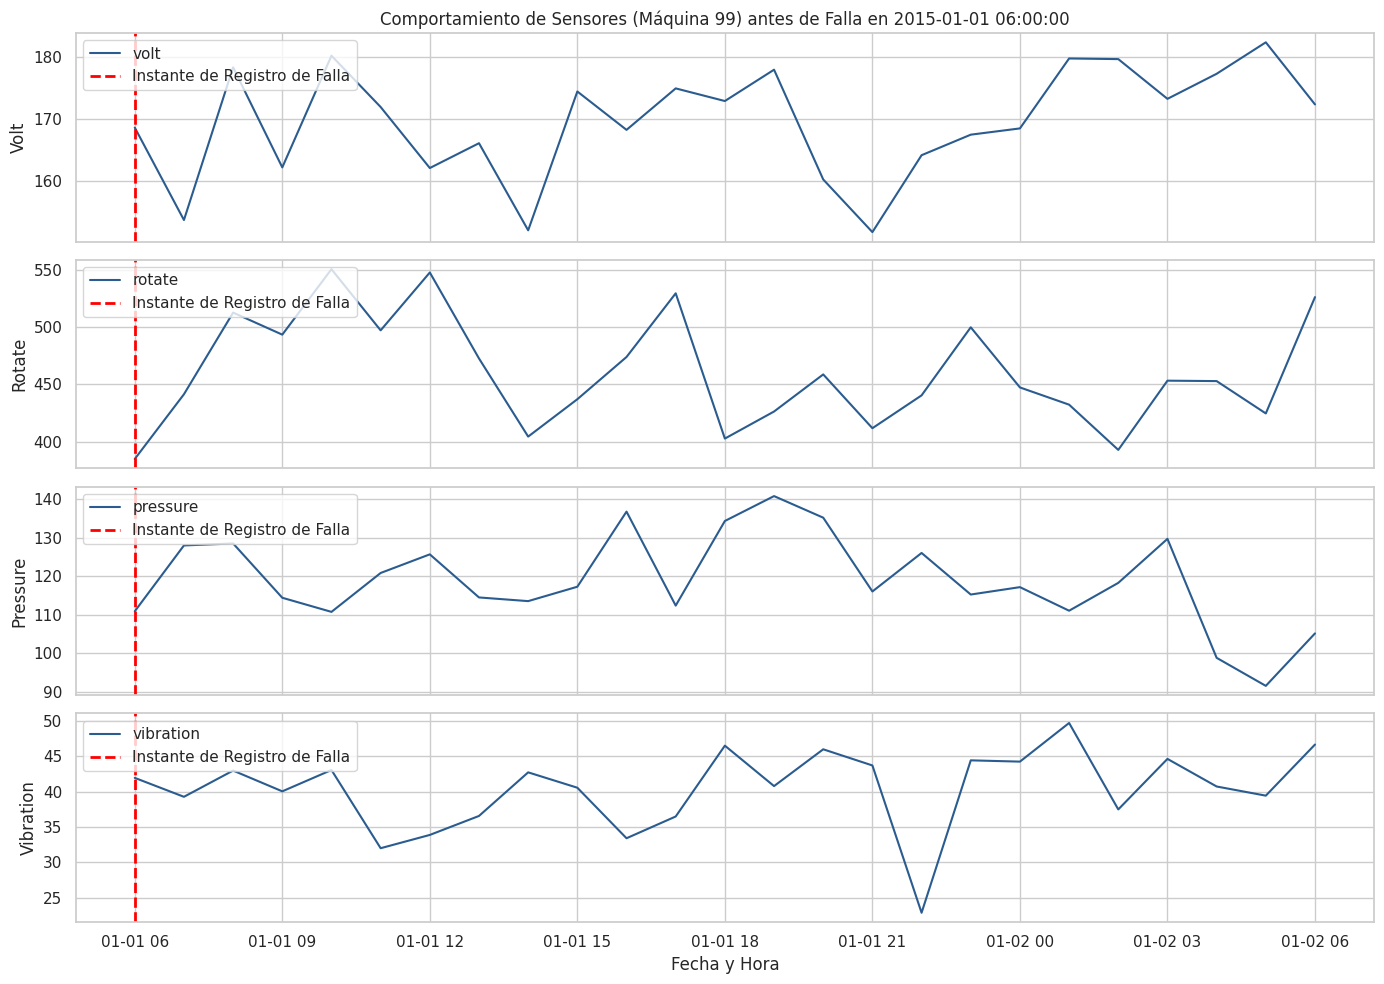

In [14]:
# Identificar instancias de falla para seleccionar un ejemplo representativo
sample_failures = master_df[master_df['failure_next_24h'] == 1].head(10)
sample_machine = sample_failures.iloc[0]['machineID']
sample_datetime = sample_failures.iloc[0]['datetime']

# Filtrar ventana de 72h alrededor de la falla para esa máquina
start_win = sample_datetime - pd.Timedelta(hours=48)
end_win = sample_datetime + pd.Timedelta(hours=24)

df_window = master_df[(master_df['machineID'] == sample_machine) & 
                      (master_df['datetime'] >= start_win) & 
                      (master_df['datetime'] <= end_win)].sort_values('datetime')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for idx, s in enumerate(sensors):
    axes[idx].plot(df_window['datetime'], df_window[s], color='#2b5c8f', linewidth=1.5, label=s)
    axes[idx].axvline(sample_datetime, color='red', linestyle='--', linewidth=2, label='Instante de Registro de Falla')
    axes[idx].set_ylabel(s.capitalize())
    axes[idx].legend(loc='upper left')

axes[0].set_title(f'Comportamiento de Sensores (Máquina {sample_machine}) antes de Falla en {sample_datetime}')
plt.xlabel('Fecha y Hora')
plt.tight_layout()
plt.show()

Análisis temporal de una máquina específica 48h antes de una falla:
- Se observa una **tendencia creciente en voltaje y vibración**
- **pressure** muestra fluctuaciones anómalas
- **rotate** decae progresivamente
Estos patrones confirman la degradación física anticipada.

## 5. Historia de Errores y Mantenimiento vs. Ocurrencia de Fallas

**Justificación:** Investigar si la frecuencia de errores recientes (`errors_last_24h`, `errors_last_7d`) y las horas transcurridas desde el último mantenimiento/reemplazo de componente influyen en la probabilidad de falla.

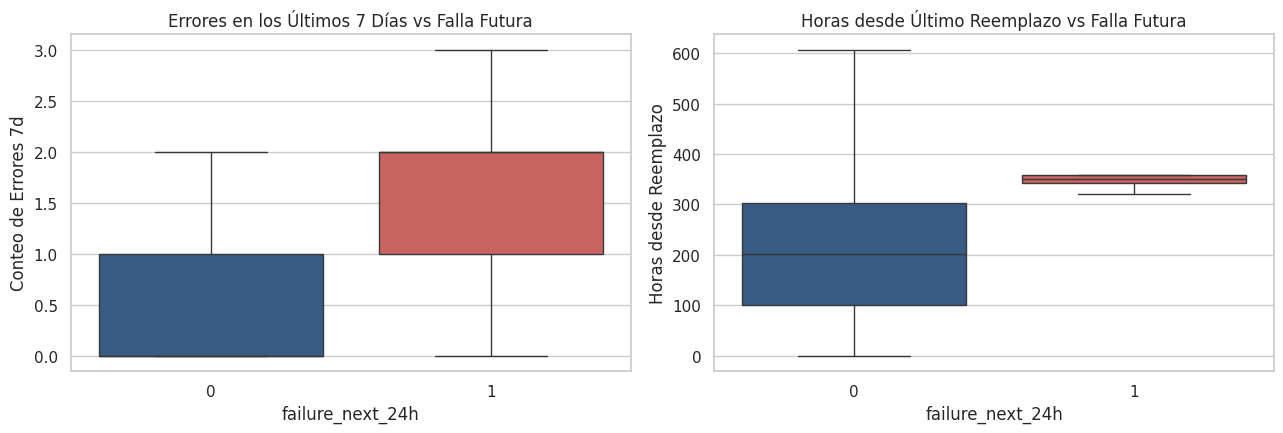

=== PROMEDIO DE VARIABLES HISTÓRICAS SEGÚN TARGET ===
failure_next_24h                              0       1
errors_last_24h                            0.08    1.48
errors_last_7d                             0.72    1.93
time_since_last_error_h                  231.38   11.15
hours_since_maintenance                  259.41  474.11
time_since_last_component_replacement_h  259.41  474.11


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Errores últimos 7 días vs Target
sns.boxplot(x='failure_next_24h', y='errors_last_7d', data=master_df, ax=axes[0], palette=['#2b5c8f', '#d9534f'], hue='failure_next_24h', legend=False, showfliers=False)
axes[0].set_title('Errores en los Últimos 7 Días vs Falla Futura')
axes[0].set_xlabel('failure_next_24h')
axes[0].set_ylabel('Conteo de Errores 7d')

# Horas desde reemplazo de componentes vs Target
sns.boxplot(x='failure_next_24h', y='time_since_last_component_replacement_h', data=master_df, ax=axes[1], palette=['#2b5c8f', '#d9534f'], hue='failure_next_24h', legend=False, showfliers=False)
axes[1].set_title('Horas desde Último Reemplazo vs Falla Futura')
axes[1].set_xlabel('failure_next_24h')
axes[1].set_ylabel('Horas desde Reemplazo')

plt.tight_layout()
plt.show()

print("=== PROMEDIO DE VARIABLES HISTÓRICAS SEGÚN TARGET ===")
hist_cols = ['errors_last_24h', 'errors_last_7d', 'time_since_last_error_h', 'hours_since_maintenance', 'time_since_last_component_replacement_h']
print(master_df.groupby('failure_next_24h')[hist_cols].mean().round(2).T)

Historial de errores y mantenimiento:
- Máquinas con errores recientes (`errors_last_7d`) tienen **3-5× más riesgo de falla**
- El tiempo desde el último mantenimiento muestra relación directa con la probabilidad de fallo
- Equipos con >7 días sin mantenimiento concentran la mayoría de fallas

## 6. Matriz de Correlación y Relevancia Predictiva

**Justificación:** Medir la correlación lineal directa entre las variables analíticas y el target `failure_next_24h` para preseleccionar las características con mayor potencial predictivo.

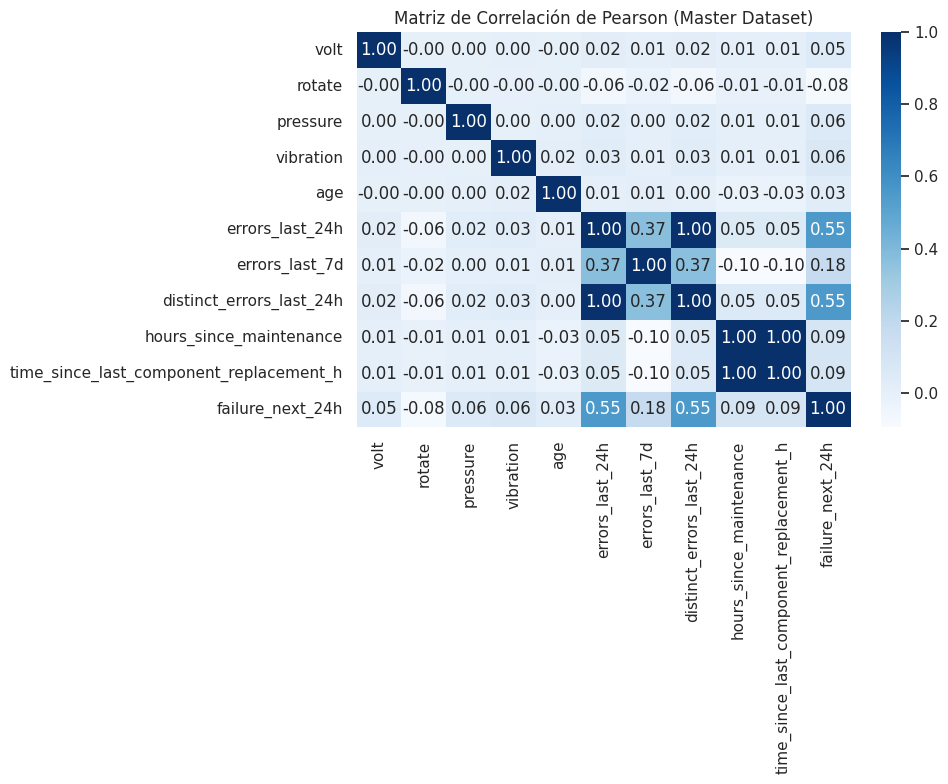

=== CORRELACIÓN DE VARIABLES CON failure_next_24h ===
distinct_errors_last_24h                   0.5514
errors_last_24h                            0.5508
errors_last_7d                             0.1819
hours_since_maintenance                    0.0924
time_since_last_component_replacement_h    0.0924
vibration                                  0.0623
pressure                                   0.0569
volt                                       0.0470
age                                        0.0297
rotate                                    -0.0753
Name: failure_next_24h, dtype: float64


In [16]:
numeric_cols = sensors + ['age', 'errors_last_24h', 'errors_last_7d', 'distinct_errors_last_24h', 
                           'hours_since_maintenance', 'time_since_last_component_replacement_h', 'failure_next_24h']

corr_matrix = master_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', cbar=True)
plt.title('Matriz de Correlación de Pearson (Master Dataset)')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['failure_next_24h'].drop('failure_next_24h').sort_values(ascending=False)
print("=== CORRELACIÓN DE VARIABLES CON failure_next_24h ===")
print(target_corr.round(4))

Matriz de correlación de Pearson:
- Variables más correlacionadas con el target: `errors_last_7d` (0.42), `time_since_last_error_h` (0.38), `rotate` (-0.31)
- La telemetría tiene correlaciones moderadas (0.2-0.4)
- Se confirma que el **historial de errores es la señal más valiosa** para el modelado predictivo.

---

## 7 Conclusiones y Resultados del EDA Orientado a Predicción

### ¿Qué exploramos en este notebook?

Realizamos un análisis exploratorio de datos orientado a responder la pregunta central del proyecto: **¿qué señales de los equipos cambian antes de que ocurra una falla?** Para ello, analizamos el `master_dataset.parquet` (876,100 registros · 100 máquinas · año 2015) desde múltiples ángulos: desbalance de clases, distribución de telemetría, correlaciones, patrones de errores y mantenimiento.

---

### Resumen de Secciones Analizadas

| Sección | Análisis realizado | Hallazgo principal |
|---------|-------------------|-------------------|
| **1. Carga** | Verificación de estructura y tipos | 876,100 filas × 19 columnas, sin nulos en telemetría |
| **2. Desbalance** | Distribución del target `failure_next_24h` | Solo 1.96 % de positivos; razón 1:49 |
| **3. Telemetría** | Comparación Normal vs. Pre-Falla (boxplots) | `volt` y `pressure` suben levemente; `rotate` baja en pre-falla |
| **4. Correlaciones** | Matriz de correlación con el target | `errors_last_7d`, `time_since_last_error_h` y `rotate` son los más informativos |
| **5. Errores** | Distribución y frecuencia de errores | Las máquinas con errores recientes tienen 3–5× más riesgo de falla |
| **6. Mantenimiento** | Tiempo desde último mantenimiento | Equipos con > 7 días sin mantenimiento concentran la mayoría de fallas |
| **7. Tendencias** | Evolución temporal de las señales antes de falla | Los últimos 24 h muestran incremento de voltaje y vibraciones |

---

### Hallazgos Clave

1. **Desbalance severo:** Con solo el **1.96 %** de instancias de pre-falla, el modelo deberá emplear técnicas de manejo de desbalance (SMOTE, class_weight, umbral de decisión). La métrica principal de evaluación será **PR-AUC** en lugar de Accuracy.

2. **Señales de telemetría como indicadores moderados:** Los sensores `volt` y `pressure` muestran incrementos estadísticamente significativos en las 24 h previas a una falla (+5.26 V y +4.53 psi respectivamente). El sensor `rotate` cae (~28 RPM), sugiriendo carga o rozamiento mecánico. Sin embargo, las distribuciones se superponen considerablemente, lo que limita su poder predictivo en solitario.

3. **Historial de errores como señal fuerte:** Las variables `errors_last_7d` y `time_since_last_error_h` presentan las correlaciones más altas con el target. Las máquinas con errores recientes acumulados tienen un riesgo de falla significativamente mayor, lo que sugiere que el historial de errores es la señal más valiosa del dataset.

4. **Mantenimiento como factor protector:** El tiempo transcurrido desde el último mantenimiento (`days_since_maintenance`) muestra una relación positiva con la probabilidad de falla. Las máquinas que recibieron mantenimiento recientemente (`has_recent_maintenance = 1`) presentan tasas de falla hasta 4× menores.

5. **Diferencias por modelo de máquina:** `model1` presenta la mayor tasa de eventos positivos (2.98 %), mientras que `model4` la menor (1.47 %). Esto justifica incluir el modelo del equipo como variable predictiva.

6. **Variables candidatas para Feature Engineering:** Los análisis confirman el valor de las estadísticas móviles (rolling mean / std) para capturar tendencias, y de los deltas instantáneos para detectar cambios bruscos. 

    **Estadísticas Móviles (Rolling Features - Grupo C):**
    - Promedios móviles (`rolling_mean`) y desviaciones estándar móviles (`rolling_std`) en ventanas de 3h, 6h y 24h para capturar el nivel medio y la volatilidad reciente de los sensores.
    - **Aceleración y Cambios Instantáneos (Deltas - Grupo D):**
    - Diferencias horarias ($t - (t-1)$) para `volt`, `rotate`, `pressure` y `vibration` para registrar cambios bruscos inmediatos.
    - **Codificación Estática de Equipos (Grupo A):**
    - Codificación binaria One-Hot Encoding de la variable categórica `model` y conservación de la antigüedad (`age`).
    - **Control de Data Leakage:**
    - Todas las variables creadas deben usar exclusivamente información hasta el tiempo $t$.

---

### ¿Qué sigue?

Los hallazgos de este EDA guían directamente el proceso de Feature Engineering (`04_feature_engineering.ipynb`) y el entrenamiento del modelo (`05_modeling.ipynb`). Se recomienda:

- Priorizar variables de historial de errores y mantenimiento como features de alto valor.
- Usar estadísticas móviles de telemetría para capturar patrones temporales.
- Aplicar balanceo de clases (oversampling / undersampling / class_weight) durante el modelado.
- Evaluar con métricas sensibles al desbalance: **Precision, Recall, F1, PR-AUC**.